# Neural ODE demo: undamped pendulum

This notebook learns a nonlinear ODE from trajectory data.

We study the undamped pendulum

$$\dot\theta = \omega, \qquad \dot\omega = -\sin(\theta),$$

and train a Neural ODE to learn the vector field from observed trajectories.

We will proceed in stages:

- Stage 1: train only on low-energy oscillatory trajectories
- Stage 2: also train on rotational trajectories that cross the separatrix
- Stage 3: use a periodic state representation $(\sin\theta, \cos\theta, \omega)$

In [1]:
config = {
    'n_train_low': 128,
    'n_test_low': 48,
    'n_train_rot_extra': 96,
    'n_test_rot': 40,
    't_final': 6.0,
    'dt': 0.05,
    'batch_size': 32,
    'hidden_dim': 64,
    'epochs_stage1': 60,
    'epochs_stage2': 40,
    'learning_rate': 3e-3,
    'learning_rate_stage2': 1e-3,
    'weight_decay': 1e-6,
    'seed': 7,
}

energy_bands = {
    'low': (0.05, 1.6),
    'rot': (2.3, 4.0),
}

theta_plot_limits = (-7.0, 7.0)
omega_plot_limits = (-3.2, 3.2)

import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

seed = config['seed']
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

Using device: cpu


## True dynamics and a simple RK4 integrator

We keep the solver inside the notebook so the Neural ODE training loop is completely transparent.

We will sample trajectories by energy band:

- low-energy trajectories satisfy $E < 2$ and oscillate
- rotational trajectories satisfy $E > 2$ and go over the top

This creates a clean train-vs-extrapolation split.


Number of time steps: 120
Separatrix energy: 2.0
low-energy train trajectories: (128, 121, 2)
low-energy test trajectories: (48, 121, 2)
rotational extra train trajectories: (96, 121, 2)
rotational test trajectories: (40, 121, 2)


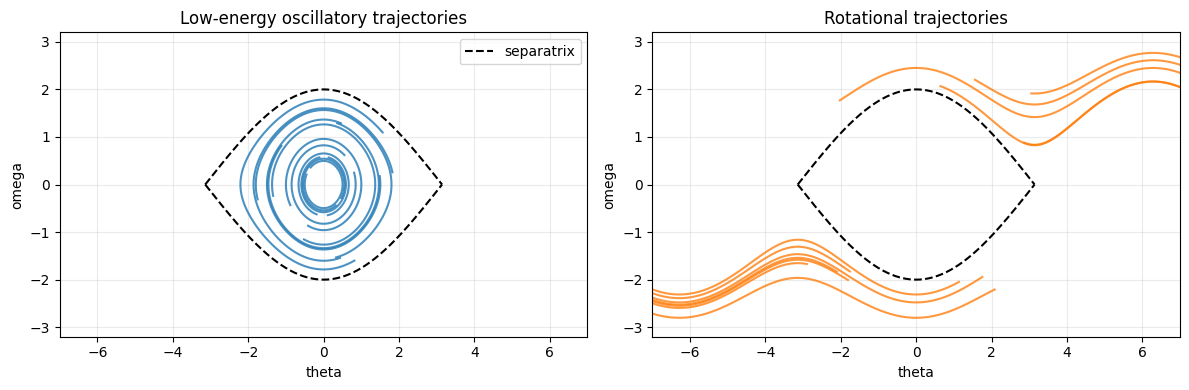

In [2]:
def pendulum_vector_field(state):
    theta = state[..., 0]
    omega = state[..., 1]
    return torch.stack([omega, -torch.sin(theta)], dim=-1)


def rk4_step(z, dt, vector_field):
    k1 = vector_field(z)
    k2 = vector_field(z + 0.5 * dt * k1)
    k3 = vector_field(z + 0.5 * dt * k2)
    k4 = vector_field(z + dt * k3)
    return z + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def rollout(z0, n_steps, dt, vector_field):
    states = [z0]
    z = z0
    for _ in range(n_steps):
        z = rk4_step(z, dt, vector_field)
        states.append(z)
    return torch.stack(states, dim=1)


def pendulum_energy(state):
    theta = state[..., 0]
    omega = state[..., 1]
    return 0.5 * omega ** 2 + 1.0 - torch.cos(theta)


def sample_initial_conditions(n_samples, energy_min, energy_max, omega_max=3.5):
    samples = []
    while len(samples) < n_samples:
        theta = (2 * math.pi) * torch.rand(4 * n_samples) - math.pi
        omega = 2 * omega_max * torch.rand(4 * n_samples) - omega_max
        states = torch.stack([theta, omega], dim=-1)
        energies = pendulum_energy(states)
        mask = (energies >= energy_min) & (energies <= energy_max)
        accepted = states[mask]
        for state in accepted:
            samples.append(state)
            if len(samples) == n_samples:
                break
    return torch.stack(samples, dim=0).float()


def make_dataset(n_samples, energy_band, n_steps, dt):
    z0 = sample_initial_conditions(n_samples, *energy_band)
    traj = rollout(z0, n_steps, dt, pendulum_vector_field).float()
    return z0, traj


n_steps = int(config['t_final'] / config['dt'])
t_grid = torch.linspace(0.0, config['t_final'], n_steps + 1)

z0_train_low, traj_train_low = make_dataset(config['n_train_low'], energy_bands['low'], n_steps, config['dt'])
z0_test_low, traj_test_low = make_dataset(config['n_test_low'], energy_bands['low'], n_steps, config['dt'])
z0_train_rot, traj_train_rot = make_dataset(config['n_train_rot_extra'], energy_bands['rot'], n_steps, config['dt'])
z0_test_rot, traj_test_rot = make_dataset(config['n_test_rot'], energy_bands['rot'], n_steps, config['dt'])

print('Number of time steps:', n_steps)
print('Separatrix energy:', 2.0)
print('low-energy train trajectories:', tuple(traj_train_low.shape))
print('low-energy test trajectories:', tuple(traj_test_low.shape))
print('rotational extra train trajectories:', tuple(traj_train_rot.shape))
print('rotational test trajectories:', tuple(traj_test_rot.shape))

theta_sep = np.linspace(-math.pi, math.pi, 400)
omega_sep = 2.0 * np.cos(theta_sep / 2.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx in range(12):
    axes[0].plot(traj_train_low[idx, :, 0].numpy(), traj_train_low[idx, :, 1].numpy(), color='tab:blue', alpha=0.8)
for idx in range(12):
    axes[1].plot(traj_test_rot[idx, :, 0].numpy(), traj_test_rot[idx, :, 1].numpy(), color='tab:orange', alpha=0.8)

for ax in axes:
    ax.plot(theta_sep, omega_sep, 'k--', linewidth=1.5, label='separatrix')
    ax.plot(theta_sep, -omega_sep, 'k--', linewidth=1.5)
    ax.set_xlim(theta_plot_limits)
    ax.set_ylim(omega_plot_limits)
    ax.set_xlabel('theta')
    ax.set_ylabel('omega')
    ax.grid(alpha=0.25)

axes[0].set_title('Low-energy oscillatory trajectories')
axes[1].set_title('Rotational trajectories')
axes[0].legend()
plt.tight_layout()
plt.show()

## Neural ODE model and training utilities

The network maps the current state $(\theta, \omega)$ to the learned time derivative $(\dot\theta, \dot\omega)$.

Training uses only trajectory mismatch after numerical integration; we do not supervise derivatives directly.


In [3]:
class NeuralODEField(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, state):
        return self.net(state)


def rollout_model(model, z0, n_steps, dt):
    return rollout(z0, n_steps, dt, model)


def relative_l2(pred, target, eps=1e-12):
    pred_flat = pred.reshape(pred.shape[0], -1)
    target_flat = target.reshape(target.shape[0], -1)
    num = torch.linalg.vector_norm(pred_flat - target_flat, dim=1)
    den = torch.linalg.vector_norm(target_flat, dim=1) + eps
    return (num / den).mean()


def evaluate_model(model, datasets):
    metrics = {}
    model.eval()
    with torch.no_grad():
        for name, (z0, true_traj) in datasets.items():
            pred_traj = rollout_model(model, z0.to(device), n_steps, config['dt']).cpu()
            mse = torch.mean((pred_traj - true_traj) ** 2).item()
            rel = relative_l2(pred_traj, true_traj).item()
            metrics[name] = {'mse': mse, 'rel_l2': rel}
    return metrics


def train_model(model, train_loader, eval_datasets, epochs, learning_rate):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=config['weight_decay'],
    )
    history = {'train_mse': [], 'low_rel_l2': [], 'rot_rel_l2': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for z0_batch, traj_batch in train_loader:
            z0_batch = z0_batch.to(device)
            traj_batch = traj_batch.to(device)

            optimizer.zero_grad()
            pred_traj = rollout_model(model, z0_batch, n_steps, config['dt'])
            loss = torch.mean((pred_traj - traj_batch) ** 2)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * z0_batch.size(0)

        train_loss /= len(train_loader.dataset)
        metrics = evaluate_model(model, eval_datasets)

        history['train_mse'].append(train_loss)
        history['low_rel_l2'].append(metrics['low']['rel_l2'])
        history['rot_rel_l2'].append(metrics['rot']['rel_l2'])

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1:3d} | train MSE = {train_loss:.6f} | "
                f"low rel L2 = {metrics['low']['rel_l2']:.4f} | rot rel L2 = {metrics['rot']['rel_l2']:.4f}"
            )

    return history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

    axes[0].plot(history['train_mse'], label='train MSE')
    axes[0].set_title(title)
    axes[0].set_yscale('log')
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(history['low_rel_l2'], label='low-energy test')
    axes[1].plot(history['rot_rel_l2'], label='rotational test')
    axes[1].set_title('Trajectory relative error')
    axes[1].set_yscale('log')
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def get_grid_field(model=None, theta_lim=(-7.0, 7.0), omega_lim=(-3.2, 3.2), n_theta=121, n_omega=101):
    theta_vals = np.linspace(theta_lim[0], theta_lim[1], n_theta)
    omega_vals = np.linspace(omega_lim[0], omega_lim[1], n_omega)
    theta_grid, omega_grid = np.meshgrid(theta_vals, omega_vals)
    states = torch.tensor(np.stack([theta_grid, omega_grid], axis=-1), dtype=torch.float32)
    flat_states = states.reshape(-1, 2)

    with torch.no_grad():
        if model is None:
            deriv = pendulum_vector_field(flat_states)
        else:
            deriv = model(flat_states.to(device)).cpu()

    deriv = deriv.reshape(n_omega, n_theta, 2).numpy()
    return theta_vals, omega_vals, deriv[..., 0], deriv[..., 1]


def plot_vector_field_comparison(model, title, overlay_groups=None):
    if overlay_groups is None:
        overlay_groups = [
            {
                'traj': traj_train_low,
                'count': 8,
                'color': 'tab:orange',
                'alpha': 0.6,
                'linewidth': 1.2,
                'label': 'low-energy train',
            }
        ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

    for ax, field_model, subtitle in [
        (axes[0], None, 'True vector field'),
        (axes[1], model, title),
    ]:
        theta_vals, omega_vals, dtheta, domega = get_grid_field(field_model, theta_plot_limits, omega_plot_limits)
        speed = np.sqrt(dtheta ** 2 + domega ** 2)
        ax.streamplot(theta_vals, omega_vals, dtheta, domega, color=speed, cmap='viridis', density=1.0)
        ax.plot(theta_sep, omega_sep, 'w--', linewidth=1.5)
        ax.plot(theta_sep, -omega_sep, 'w--', linewidth=1.5)

        for group in overlay_groups:
            traj = group['traj']
            count = min(group.get('count', 8), traj.shape[0])
            color = group.get('color', 'tab:orange')
            alpha = group.get('alpha', 0.6)
            linewidth = group.get('linewidth', 1.2)
            label = group.get('label')

            for idx in range(count):
                current_label = label if idx == 0 else None
                ax.plot(
                    traj[idx, :, 0].numpy(),
                    traj[idx, :, 1].numpy(),
                    color=color,
                    alpha=alpha,
                    linewidth=linewidth,
                    label=current_label,
                )

        ax.set_title(subtitle)
        ax.set_xlabel('theta')
        ax.set_ylabel('omega')
        ax.set_xlim(theta_plot_limits)
        ax.set_ylim(omega_plot_limits)
        if any(group.get('label') for group in overlay_groups):
            ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


def plot_rollout_examples(model, low_indices=(0, 1), rot_indices=(0, 1), title=''):
    chosen_z0 = torch.cat([z0_test_low[list(low_indices)], z0_test_rot[list(rot_indices)]], dim=0)
    chosen_true = torch.cat([traj_test_low[list(low_indices)], traj_test_rot[list(rot_indices)]], dim=0)
    labels = [f'low test {idx}' for idx in low_indices] + [f'rot test {idx}' for idx in rot_indices]

    model.eval()
    with torch.no_grad():
        chosen_pred = rollout_model(model, chosen_z0.to(device), n_steps, config['dt']).cpu()

    fig, axes = plt.subplots(len(labels), 2, figsize=(11, 2.4 * len(labels)), sharex='col')
    if len(labels) == 1:
        axes = axes[None, :]

    for row, label in enumerate(labels):
        ax_time = axes[row, 0]
        ax_phase = axes[row, 1]

        ax_time.plot(t_grid.numpy(), chosen_true[row, :, 0].numpy(), label='true theta', linewidth=2)
        ax_time.plot(t_grid.numpy(), chosen_pred[row, :, 0].numpy(), '--', label='pred theta', linewidth=2)
        ax_time.set_ylabel(label)
        ax_time.grid(alpha=0.25)

        ax_phase.plot(chosen_true[row, :, 0].numpy(), chosen_true[row, :, 1].numpy(), label='true', linewidth=2)
        ax_phase.plot(chosen_pred[row, :, 0].numpy(), chosen_pred[row, :, 1].numpy(), '--', label='pred', linewidth=2)
        ax_phase.grid(alpha=0.25)
        ax_phase.set_xlim(theta_plot_limits)
        ax_phase.set_ylim(omega_plot_limits)

    axes[0, 0].set_title(title + ' : theta(t)')
    axes[0, 1].set_title(title + ' : phase portrait')
    axes[0, 0].legend()
    axes[0, 1].legend()
    axes[-1, 0].set_xlabel('time')
    axes[-1, 1].set_xlabel('theta')
    plt.tight_layout()
    plt.show()


num_params = sum(p.numel() for p in NeuralODEField(hidden_dim=config['hidden_dim']).parameters())
print('Number of parameters:', num_params)

Number of parameters: 4482


## Stage 1: train only on low-energy trajectories

The model sees only oscillatory trajectories below the separatrix.


Epoch   1 | train MSE = 1.372235 | low rel L2 = 0.9934 | rot rel L2 = 0.9666
Epoch  10 | train MSE = 0.575266 | low rel L2 = 0.7752 | rot rel L2 = 0.9567
Epoch  20 | train MSE = 0.015279 | low rel L2 = 0.1415 | rot rel L2 = 0.9640
Epoch  30 | train MSE = 0.009880 | low rel L2 = 0.1129 | rot rel L2 = 0.9555
Epoch  40 | train MSE = 0.009216 | low rel L2 = 0.1101 | rot rel L2 = 0.9429
Epoch  50 | train MSE = 0.008152 | low rel L2 = 0.1046 | rot rel L2 = 0.9498
Epoch  60 | train MSE = 0.006951 | low rel L2 = 0.0963 | rot rel L2 = 0.9380


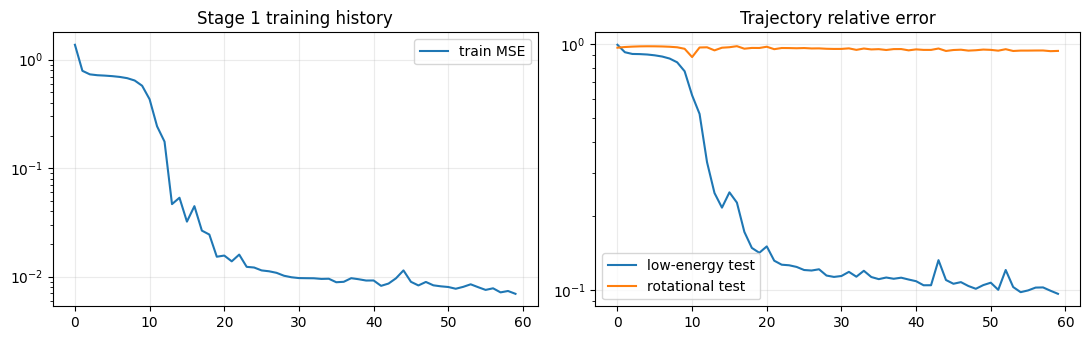

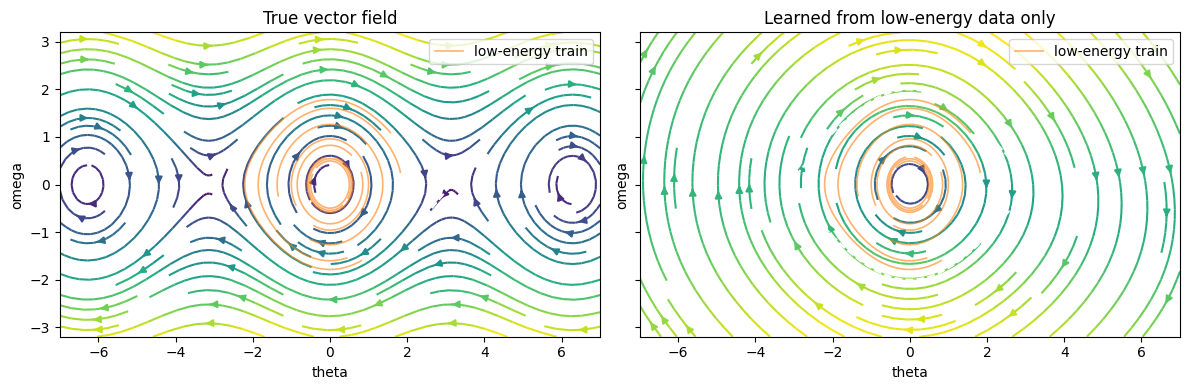

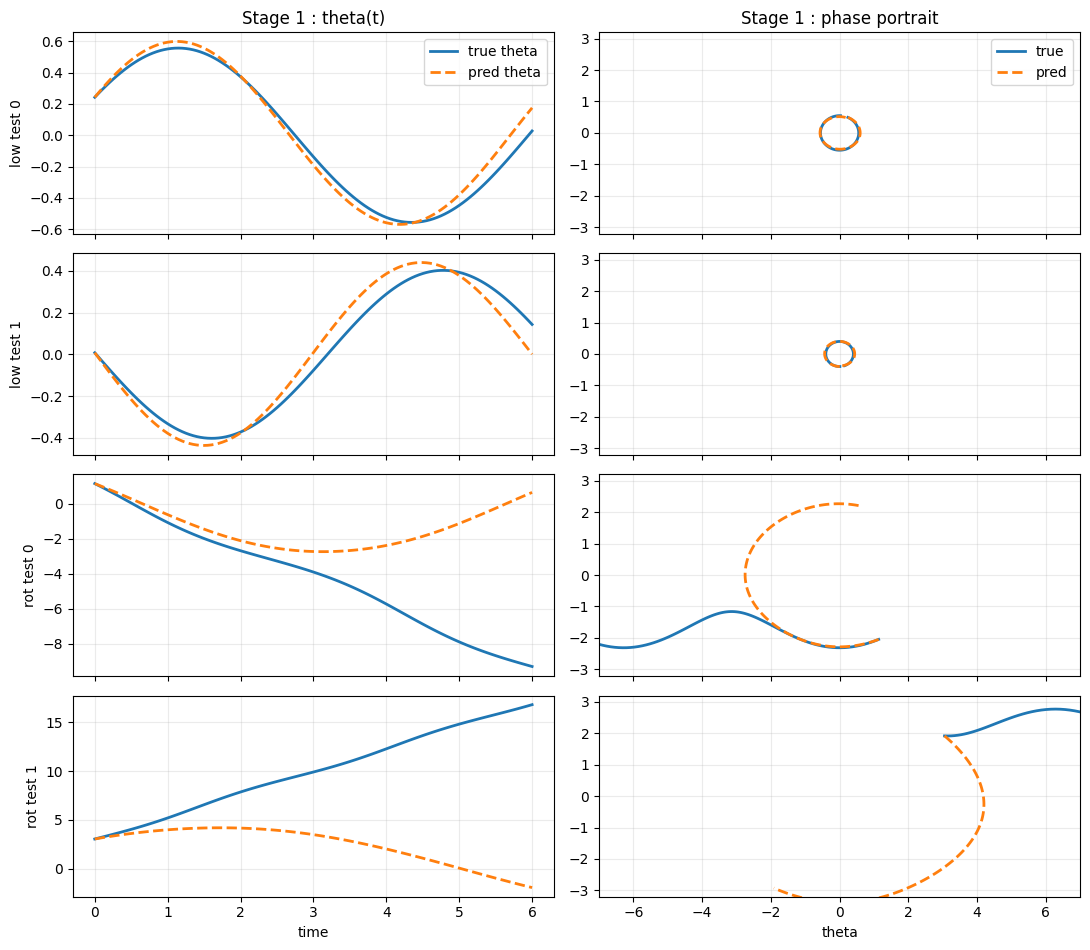

In [4]:
train_loader_stage1 = DataLoader(
    TensorDataset(z0_train_low, traj_train_low),
    batch_size=config['batch_size'],
    shuffle=True,
)

eval_datasets = {
    'low': (z0_test_low, traj_test_low),
    'rot': (z0_test_rot, traj_test_rot),
}

model_stage1 = NeuralODEField(hidden_dim=config['hidden_dim']).to(device)
history_stage1 = train_model(
    model_stage1,
    train_loader_stage1,
    eval_datasets,
    epochs=config['epochs_stage1'],
    learning_rate=config['learning_rate'],
)

plot_history(history_stage1, title='Stage 1 training history')
plot_vector_field_comparison(model_stage1, title='Learned from low-energy data only')
plot_rollout_examples(model_stage1, title='Stage 1')

## Stage 2: add rotational trajectories

Now we expand the training set with trajectories above the separatrix and continue training from the Stage 1 model.

That makes the comparison closer to what we would do in practice: keep what was already learned, then enlarge the domain with more data.


Epoch   1 | train MSE = 7.602460 | low rel L2 = 1.6549 | rot rel L2 = 0.4541
Epoch  10 | train MSE = 1.340457 | low rel L2 = 0.6601 | rot rel L2 = 0.2313
Epoch  20 | train MSE = 0.277424 | low rel L2 = 0.4422 | rot rel L2 = 0.1230
Epoch  30 | train MSE = 0.195187 | low rel L2 = 0.3220 | rot rel L2 = 0.1172
Epoch  40 | train MSE = 0.169359 | low rel L2 = 0.2742 | rot rel L2 = 0.1152


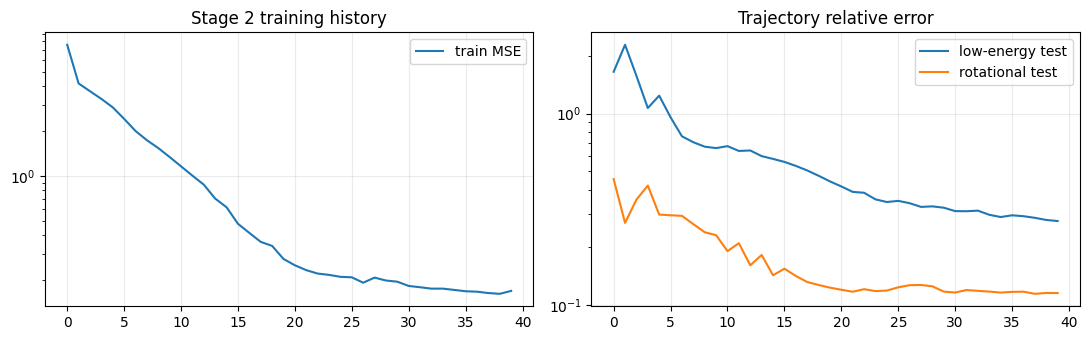

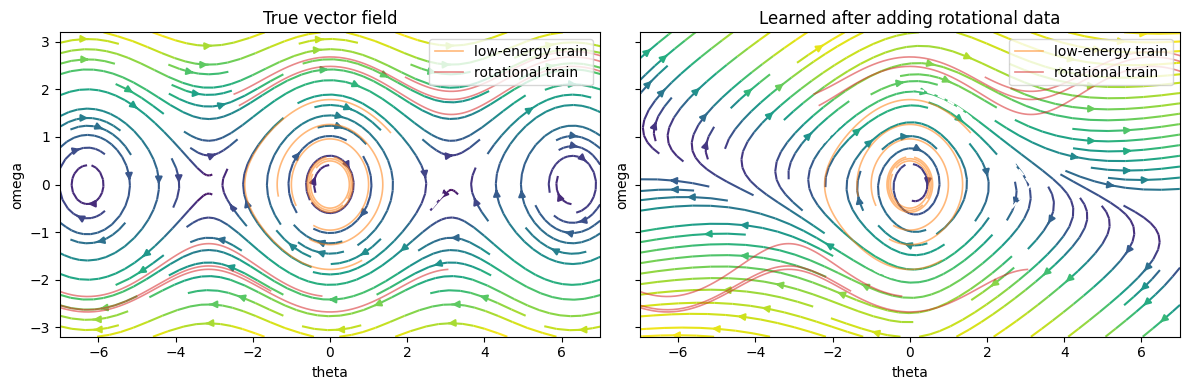

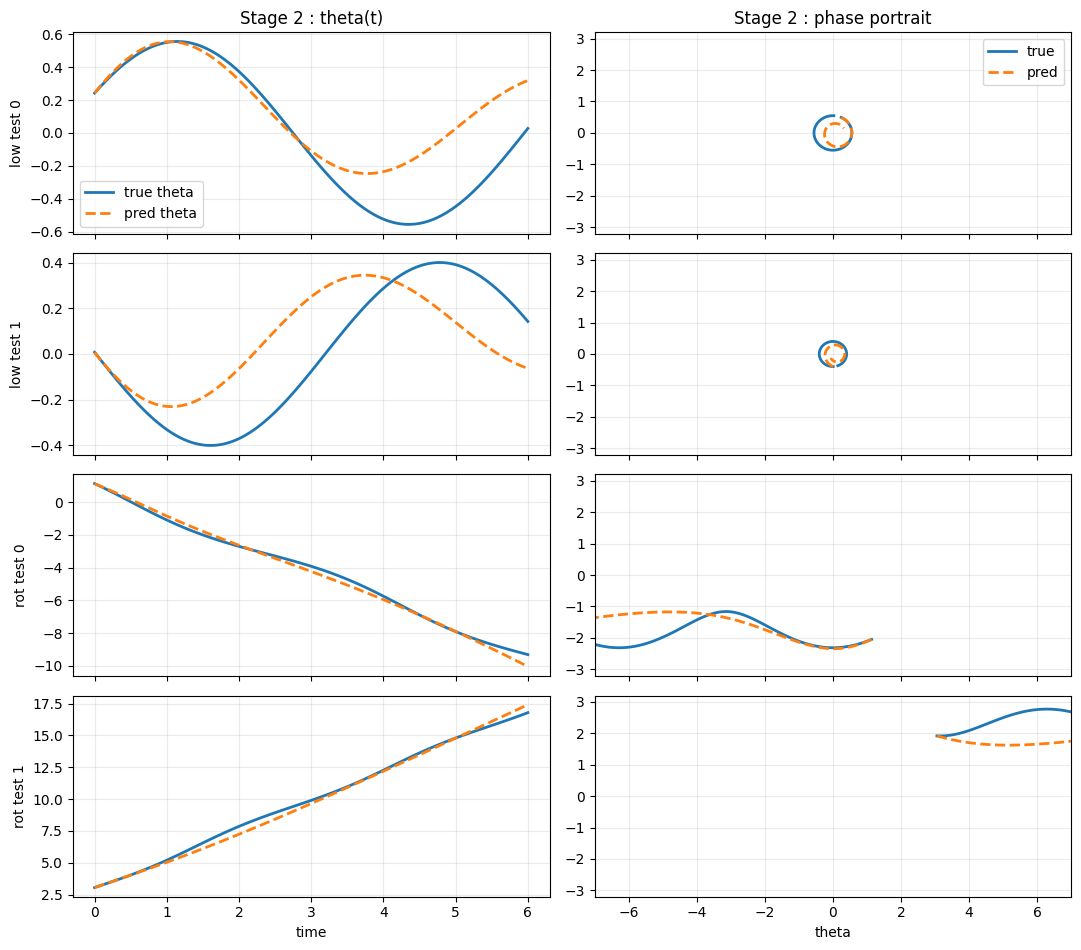

Stage 1 metrics (low-energy only):
   low | mse = 0.008199 | rel_l2 = 0.0963
   rot | mse = 26.143196 | rel_l2 = 0.9380

Stage 2 metrics (rotational data added):
   low | mse = 0.052521 | rel_l2 = 0.2742
   rot | mse = 0.325607 | rel_l2 = 0.1152


In [5]:
z0_train_aug = torch.cat([z0_train_low, z0_train_rot], dim=0)
traj_train_aug = torch.cat([traj_train_low, traj_train_rot], dim=0)

train_loader_stage2 = DataLoader(
    TensorDataset(z0_train_aug, traj_train_aug),
    batch_size=config['batch_size'],
    shuffle=True,
)

model_stage2 = NeuralODEField(hidden_dim=config['hidden_dim']).to(device)
model_stage2.load_state_dict(model_stage1.state_dict())
history_stage2 = train_model(
    model_stage2,
    train_loader_stage2,
    eval_datasets,
    epochs=config['epochs_stage2'],
    learning_rate=config['learning_rate_stage2'],
)

plot_history(history_stage2, title='Stage 2 training history')
plot_vector_field_comparison(
    model_stage2,
    title='Learned after adding rotational data',
    overlay_groups=[
        {
            'traj': traj_train_low,
            'count': 6,
            'color': 'tab:orange',
            'alpha': 0.55,
            'linewidth': 1.2,
            'label': 'low-energy train',
        },
        {
            'traj': traj_train_rot,
            'count': 6,
            'color': 'tab:red',
            'alpha': 0.55,
            'linewidth': 1.2,
            'label': 'rotational train',
        },
    ],
)
plot_rollout_examples(model_stage2, title='Stage 2')

metrics_stage1 = evaluate_model(model_stage1, eval_datasets)
metrics_stage2 = evaluate_model(model_stage2, eval_datasets)

print('Stage 1 metrics (low-energy only):')
for name, values in metrics_stage1.items():
    print(f"  {name:>4s} | mse = {values['mse']:.6f} | rel_l2 = {values['rel_l2']:.4f}")

print('')
print('Stage 2 metrics (rotational data added):')
for name, values in metrics_stage2.items():
    print(f"  {name:>4s} | mse = {values['mse']:.6f} | rel_l2 = {values['rel_l2']:.4f}")

## Stage 3: Periodic state representation: $(\sin\theta, \cos\theta, \omega)$

A natural way to encode the pendulum geometry is to represent angle through its sine and cosine.

Here we train another Neural ODE on all training data, but the vector-field network now sees $(\sin\theta, \cos\theta, \omega)$ instead of raw $(\theta, \omega)$.

This makes the periodic structure of the angle explicit while keeping the learned dynamics in the original variables $(\theta, \omega)$.


Epoch   1 | train MSE = 5.738419 | low rel L2 = 1.2225 | rot rel L2 = 0.2190
Epoch  10 | train MSE = 0.085834 | low rel L2 = 0.1806 | rot rel L2 = 0.0634
Epoch  20 | train MSE = 0.048224 | low rel L2 = 0.1309 | rot rel L2 = 0.0657
Epoch  30 | train MSE = 0.036664 | low rel L2 = 0.0910 | rot rel L2 = 0.0462
Epoch  40 | train MSE = 0.027785 | low rel L2 = 0.1249 | rot rel L2 = 0.0436


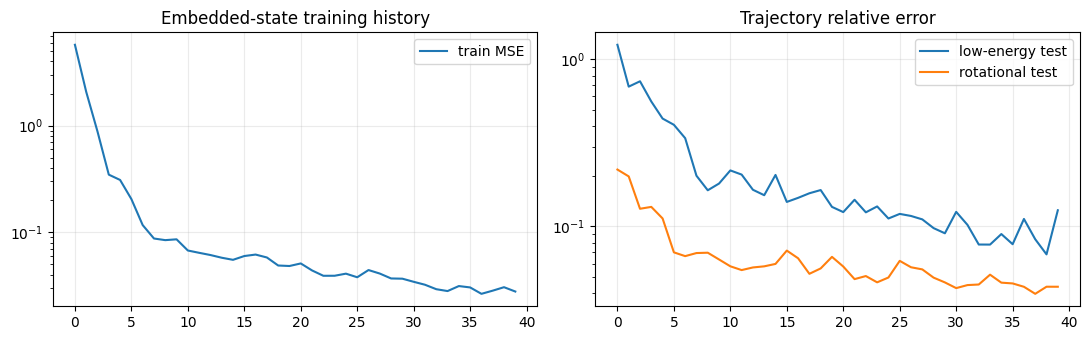

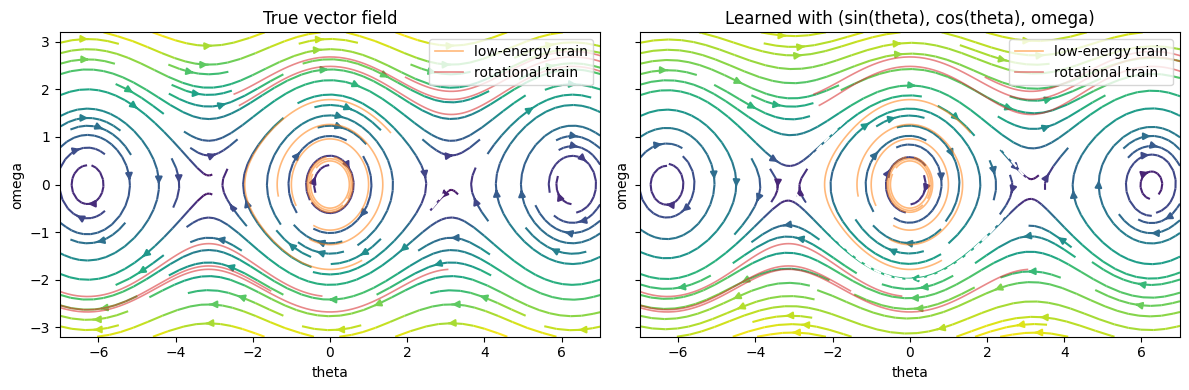

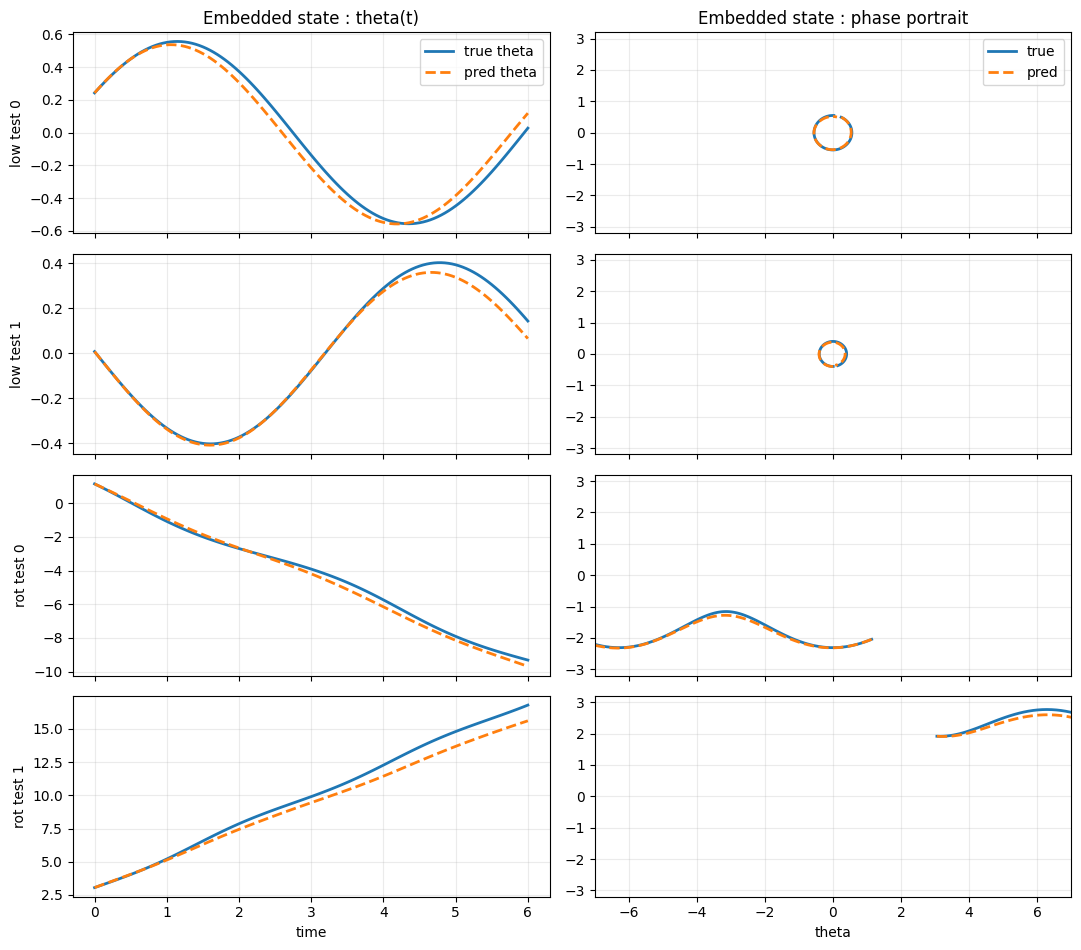

Stage 1 metrics (low-energy only):
   low | mse = 0.008199 | rel_l2 = 0.0963
   rot | mse = 26.143196 | rel_l2 = 0.9380

Stage 2 metrics (rotational data added):
   low | mse = 0.052521 | rel_l2 = 0.2742
   rot | mse = 0.325607 | rel_l2 = 0.1152

Stage 3 metrics (embedded-state):
   low | mse = 0.021173 | rel_l2 = 0.1249
   rot | mse = 0.052577 | rel_l2 = 0.0436


In [6]:
class EmbeddedNeuralODEField(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, state):
        theta = state[..., 0]
        omega = state[..., 1]
        features = torch.stack([torch.sin(theta), torch.cos(theta), omega], dim=-1)
        return self.net(features)


model_embedded = EmbeddedNeuralODEField(hidden_dim=config['hidden_dim']).to(device)
history_embedded = train_model(
    model_embedded,
    train_loader_stage2,
    eval_datasets,
    epochs=config['epochs_stage2'],
    learning_rate=config['learning_rate'],
)

plot_history(history_embedded, title='Embedded-state training history')
plot_vector_field_comparison(
    model_embedded,
    title='Learned with (sin(theta), cos(theta), omega)',
    overlay_groups=[
        {
            'traj': traj_train_low,
            'count': 6,
            'color': 'tab:orange',
            'alpha': 0.55,
            'linewidth': 1.2,
            'label': 'low-energy train',
        },
        {
            'traj': traj_train_rot,
            'count': 6,
            'color': 'tab:red',
            'alpha': 0.55,
            'linewidth': 1.2,
            'label': 'rotational train',
        },
    ],
)
plot_rollout_examples(model_embedded, title='Embedded state')

metrics_embedded = evaluate_model(model_embedded, eval_datasets)

print('Stage 1 metrics (low-energy only):')
for name, values in metrics_stage1.items():
    print(f"  {name:>4s} | mse = {values['mse']:.6f} | rel_l2 = {values['rel_l2']:.4f}")

print('')
print('Stage 2 metrics (rotational data added):')
for name, values in metrics_stage2.items():
    print(f"  {name:>4s} | mse = {values['mse']:.6f} | rel_l2 = {values['rel_l2']:.4f}")

print('')
print('Stage 3 metrics (embedded-state):')
for name, values in metrics_embedded.items():
    print(f"  {name:>4s} | mse = {values['mse']:.6f} | rel_l2 = {values['rel_l2']:.4f}")

## Takeaways

A Neural ODE can learn the pendulum flow very well on the part of phase space covered by training trajectories.

But without the right data coverage, a generic neural vector field does not automatically discover the full global structure of the system.

Using $(\sin\theta, \cos\theta, \omega)$ is one principled way to encode the periodic geometry of the pendulum while still learning dynamics in the original phase variables.